# Unstable Linear time-varying system with Proportional Control
reference: [github.com/VArdulov/online_dmd](https://github.com/VArdulov/online_dmd)

In [1]:
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from river.decomposition.odmd import OnlineDMD, OnlineDMDwC

sys.path.append("..")
from functions.plot import set_size
from functions.rolling import Rolling

In [2]:
%load_ext autoreload
%autoreload 2

## Generating the data

We define our data as 100 evenly spaced snap shots along $0 \leq t < 10$, such that $\Delta t = 0.1$. Our "true" continuous time model dynamics are given by:
$$
\dot{x} = A(t)x(t)
$$
where
$$
A(t) = \begin{bmatrix}
1 & \omega(t) \\
-\omega(t) & 0.1
\end{bmatrix}
$$
and
$$
\omega(t) = 1 + \epsilon t
$$
where $\epsilon$ is chosen to $0.1$

We assume a known controller $B$:
$$
B = \begin{bmatrix}
1 \\
0
\end{bmatrix}
$$

We then use this to compute our 100 time snap shots and eigen-values below:


In [3]:
epsilon = 1e-1
K_prop = -1
B = np.array([1, 0])


def omega(t):
    return 1 + epsilon * t


def u_t(x):
    return K_prop * x


T = 10
dt = 0.01
iterations = int(T / dt)
tspan = np.linspace(0, T, num=iterations)
t = tspan[1:]

x0 = [4.0, 7.0]
X = np.zeros((iterations, 2))
X[0, :] = x0
X_auto = np.zeros((iterations, 2))
X_auto[0, :] = x0

U = np.zeros((iterations, 1))

np.random.seed(0)
# true dynamics, true eigenvalues
n, m = X.shape[0] - 1, X.shape[1]
gt_eigvals = np.empty((n, m), dtype=complex)
for k, t_ in enumerate(t):
    A_t = np.matrix([[dt, -omega(t_)], [omega(t_), 0.1 * dt]])
    gt_eigvals[k] = np.log(np.linalg.eig(A_t)[0])

    control_input = np.matmul(B, u_t(X[k]).T) * dt
    U[k + 1, :] = control_input
    X[k + 1, :] = (
        np.matmul(X[k, :], A_t) * dt
        + X[k, :]
        # + np.random.normal(0, 0.1)
        + control_input
    )
    X_auto[k + 1, :] = (
        np.matmul(X_auto[k, :], A_t) * dt + X_auto[k, :]
        # + np.random.normal(0, 0.1)
    )
x = X[:-1, :]
y = X[1:, :]
u = U[:-1, :]

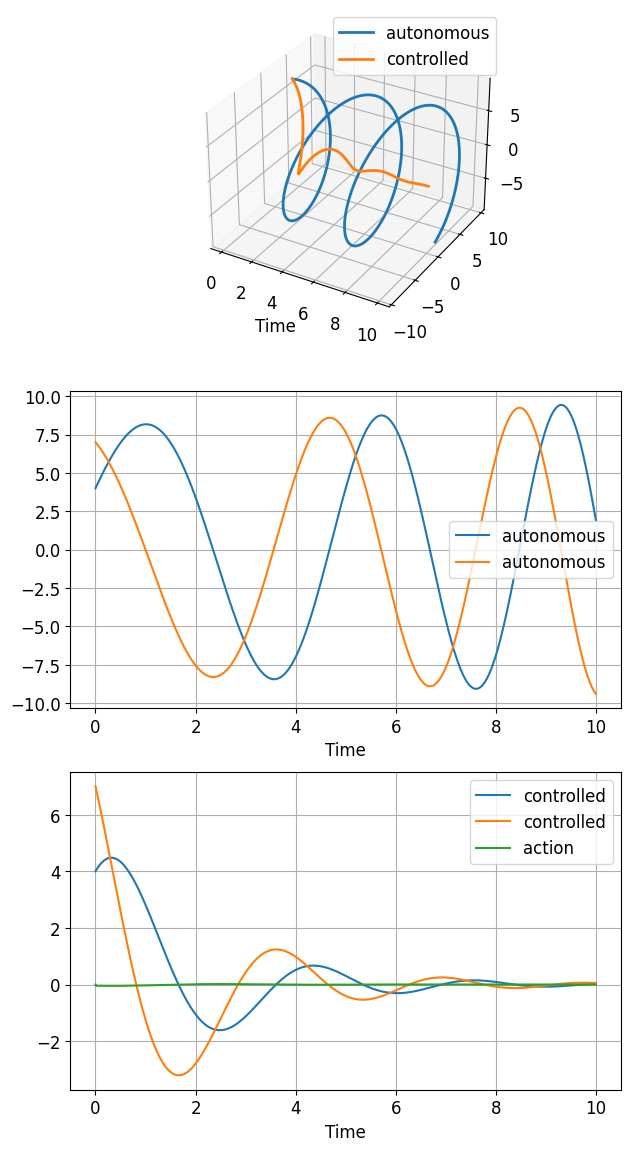

In [4]:
fig, axs = plt.subplots(3, 1, figsize=set_size("article", 1, (3, 1)))
axs[0].remove()  # Remove the existing 2D subplot
axs[0] = fig.add_subplot(311, projection="3d")
axs[0].plot(
    tspan, X_auto[:, 0], X_auto[:, 1], linewidth=2.0, label="autonomous"
)
axs[0].plot(tspan, X[:, 0], X[:, 1], linewidth=2.0, label="controlled")

axs[1].plot(tspan, X_auto, label="autonomous")

axs[2].plot(tspan, X, label="controlled")
axs[2].plot(tspan, U, label="action")

for ax in axs:
    ax.set_xlabel("Time")
    ax.legend()
    ax.grid(True)

## Model-fitting

Below we first initialize the fit on the first 10 samples then proceed to update the model one sample point at a time.

We also compute the continuous time eigen values at each time step to compare with those we generate above. The relationship (again from the literature) is that the discrete time DMD eigen values $\mu_{\mathrm{DMD}}$ are transposed into continuous time eigenvalues $\lambda_{\mathrm{DMD}}$ by:
$$
\lambda_{\mathrm{DMD}} = \frac{\ln(\mu_{\mathrm{DMD}})}{\Delta t}
$$

In [5]:
# Row-wise SSE
def sse(x, y):
    return np.linalg.norm(x - y)

In [6]:
import inspect

w = 10
models = {
    "Online DMD, wf=1.0": OnlineDMD(initialize=10),
    "Window DMD, w=w, wf=1.0": Rolling(
        OnlineDMD(initialize=10),
        window_size=w,
    ),
    # "Online DMD w C, batches, wf=1.0": OnlineDMDwC(initialize=10),
    "Online DMD w C, wf=1.0": OnlineDMDwC(initialize=10),
    "Online DMD w C, wf=0.995": OnlineDMDwC(
        initialize=10, w=0.995, exponential_weighting=True
    ),
    "Window DMD, w=10, wf=0.95": Rolling(
        OnlineDMD(w=0.95, exponential_weighting=True), window_size=w
    ),
    "Window DMD w C, w=w, wf=1.0": Rolling(OnlineDMDwC(), window_size=w),
    "Online DMD w C, B, wf=1.0": OnlineDMDwC(
        initialize=10, B=B.reshape(-1, 1)
    ),
    "Window DMD w C, B, w=w, wf=1.0": Rolling(
        OnlineDMDwC(B=B.reshape(-1, 1)), window_size=w
    ),
}

eigvals: dict[str, np.ndarray] = {}
sses: dict[str, tuple[np.floating, np.floating]] = {}
exectimes: dict[str, float] = {}
for name, model in models.items():
    start = time.time()
    # model.learn_many(x[:, :w].T, y[:, :w].T)
    eigvals[name] = np.empty((n, m), dtype=complex)
    for k, (x_, y_, u_) in enumerate(zip(x, y, u)):
        # if k >= w:  # in case of learn_many
        if "u" in inspect.signature(model.learn_one).parameters:
            model.learn_one(x_, y_, u_)  # type: ignore
        else:
            model.learn_one(x_, y_)
        eigvals[name][k] = np.log(np.linalg.eigvals(model.A)) / dt
    end = time.time()
    sses[name] = (
        sse(gt_eigvals[w:, 0].real, eigvals[name][w:, 0].real),
        sse(gt_eigvals[w:, 0].imag, eigvals[name][w:, 0].imag),
    )
    exectimes[name] = end - start
    print(f"{name}, time = {exectimes[name]:.2f}s")

Online DMD, wf=1.0, time = 0.03s
Window DMD, w=w, wf=1.0, time = 0.04s
Online DMD w C, wf=1.0, time = 0.03s
Online DMD w C, wf=0.995, time = 0.03s
Window DMD, w=10, wf=0.95, time = 0.03s
Window DMD w C, w=w, wf=1.0, time = 0.04s
Online DMD w C, B, wf=1.0, time = 0.03s


Window DMD w C, B, w=w, wf=1.0, time = 0.04s


In [7]:
name = "Online DMD w C, batches, wf=1.0"
model = OnlineDMDwC(initialize=10)

start = time.time()
eigvals[name] = np.empty((n, m), dtype=complex)

model.learn_many(x[:w, :], y[:w, :], u[:w, :])
model.learn_many(x[w:, :], y[w:, :], u[w:, :])
eigvals[name][:, :] = np.log(np.linalg.eigvals(model.A)) / dt
end = time.time()
sses[name] = (
    sse(gt_eigvals[w:, 0].real, eigvals[name][w:, 0].real),
    sse(gt_eigvals[w:, 0].imag, eigvals[name][w:, 0].imag),
)
exectimes[name] = end - start
print(f"{name}, time = {exectimes[name]:.2f}s")

Online DMD w C, batches, wf=1.0, time = 0.03s


## Visualization

Below we reproduce successfully the results presented in the literature, demonstrating the ability of Online DMD methods to accurately capture time-varying dynamics

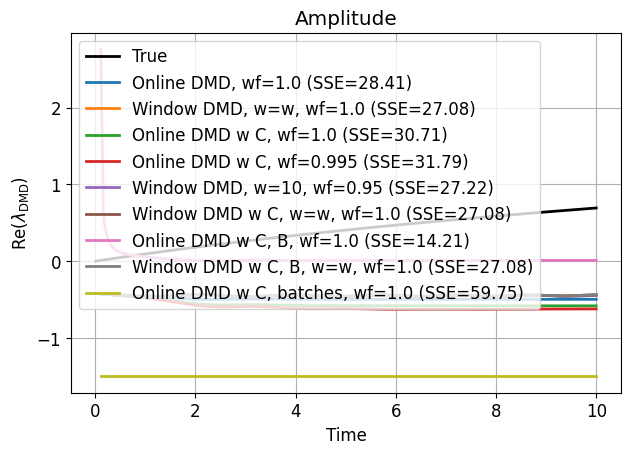

In [8]:
# [donotremove]
fig, axs = plt.subplots(figsize=set_size("article", fraction=1))

plt.plot(t, gt_eigvals[:, 0].real, "k-", label="True", linewidth=2.0)

for name, result in eigvals.items():
    axs.plot(
        t[w:],
        result[w:, 0].real,
        label=f"{name} (SSE={sses[name][0]:.2f})",
        linewidth=2.0,
    )

# Set title and font properties
axs.set_title("Amplitude")
axs.set_xlabel("Time")
axs.set_ylabel("Re($\\lambda_{\\mathrm{DMD}}$)")
axs.legend()
axs.grid(True)

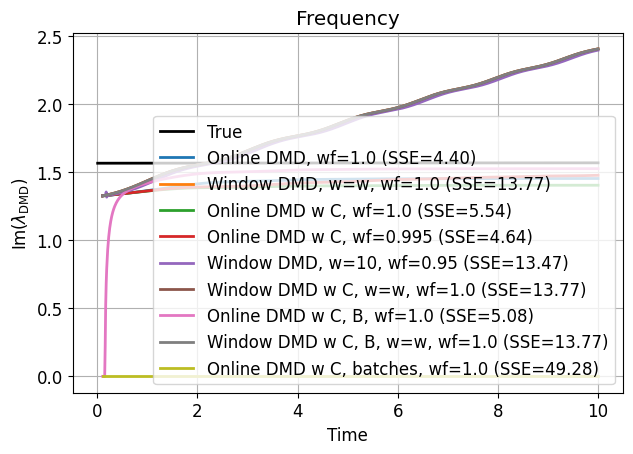

In [9]:
# [donotremove]
fig, axs = plt.subplots(figsize=set_size("article", fraction=1))

plt.plot(t, gt_eigvals[:, 0].imag, "k-", label="True", linewidth=2.0)

for name, result in eigvals.items():
    axs.plot(
        t[w:],
        result[w:, 0].imag,
        label=f"{name} (SSE={sses[name][1]:.2f})",
        linewidth=2.0,
    )

# Set title and font properties
axs.set_title("Frequency")
axs.set_xlabel("Time")
axs.set_ylabel("Im($\\lambda_{\\mathrm{DMD}}$)")
axs.legend()
axs.grid(True)